# Cell 1 – Setup:

In [1]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
import pandas as pd
import numpy as np
from PIL import Image
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import json, time, copy

# Paths
BASE   = Path(r"C:\Users\npd20\Downloads\ĐACN_v2")
SPLITS = BASE / "data" / "splits"
MODELS = BASE / "models"
FIGS   = BASE / "reports" / "figures"
MODELS.mkdir(exist_ok=True)
FIGS.mkdir(exist_ok=True)

# Device
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")

# Shared hyperparameters - SAME cho tất cả model
CONFIG = {
    "img_size"   : 64,        # resize về 64x64
    "batch_size" : 64,
    "epochs"     : 30,
    "lr"         : 1e-3,
    "patience"   : 5,         # early stopping
    "num_classes": 41,
    "num_workers": 0,
}

# Label mapping
SCORES = sorted(
    [f"{i}.{d}" for i in range(0, 10) for d in [0, 3, 5, 8]] + ["10"],
    key=lambda x: float(x)
)
label2idx = {s: i for i, s in enumerate(SCORES)}
idx2label = {i: s for s, i in label2idx.items()}
print(f"Classes: {len(label2idx)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU
Classes: 41


#  Cell 2 – implement luôn:

In [2]:
class ScoreDataset(Dataset):
    def __init__(self, csv_path, transform=None):
        self.df = pd.read_csv(csv_path)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['image_path']).convert("RGB")
        if self.transform:
            img = self.transform(img)
        label_str = str(row['label'])
        if label_str == "10.0":
            label_str = "10"
        label = label2idx[label_str]
        return img, label

# Augmentation
train_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.RandomRotation(8, fill=255),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), fill=255),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG['img_size'], CONFIG['img_size'])),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# DataLoaders
train_loader = DataLoader(
    ScoreDataset(SPLITS / "train.csv", train_transform),
    batch_size=CONFIG['batch_size'], shuffle=True,
    num_workers=0, pin_memory=True
)
val_loader = DataLoader(
    ScoreDataset(SPLITS / "val.csv", val_transform),
    batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=0, pin_memory=True
)
test_loader = DataLoader(
    ScoreDataset(SPLITS / "test.csv", val_transform),
    batch_size=CONFIG['batch_size'], shuffle=False,
    num_workers=0, pin_memory=True
)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches:   {len(val_loader)}")
print(f"Test batches:  {len(test_loader)}")

# Early Stopping
class EarlyStopping:
    def __init__(self, patience=5, min_delta=0.001):
        self.patience     = patience
        self.min_delta    = min_delta
        self.counter      = 0
        self.best_loss    = None
        self.stop         = False
        self.best_weights = None

    def __call__(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.counter      = 0
            self.best_weights = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True

Train batches: 2243
Val batches:   481
Test batches:  481


# Cell 3 – Train function dùng chung:

In [3]:
def train_model(model, model_name):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG['lr'])
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
    criterion = nn.CrossEntropyLoss()
    early_stopping = EarlyStopping(patience=CONFIG['patience'])

    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    start = time.time()

    for epoch in range(CONFIG['epochs']):
        # Train
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            train_loss    += loss.item()
            train_correct += (outputs.argmax(1) == labels).sum().item()
            train_total   += labels.size(0)

        # Val
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                outputs = model(imgs)
                loss = criterion(outputs, labels)
                val_loss    += loss.item()
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total   += labels.size(0)

        # Metrics
        t_loss = train_loss / len(train_loader)
        v_loss = val_loss   / len(val_loader)
        t_acc  = train_correct / train_total
        v_acc  = val_correct   / val_total

        history["train_loss"].append(t_loss)
        history["val_loss"].append(v_loss)
        history["train_acc"].append(t_acc)
        history["val_acc"].append(v_acc)

        scheduler.step(v_loss)
        early_stopping(v_loss, model)

        print(f"[{model_name}] Epoch {epoch+1:02d} | "
              f"Train Loss: {t_loss:.4f} Acc: {t_acc:.4f} | "
              f"Val Loss: {v_loss:.4f} Acc: {v_acc:.4f}"
              + (" ← BEST" if early_stopping.counter == 0 else
                 f" (patience {early_stopping.counter}/{CONFIG['patience']})"))

        if early_stopping.stop:
            print(f"Early stopping at epoch {epoch+1}")
            break

    # Restore best weights
    model.load_state_dict(early_stopping.best_weights)
    elapsed = time.time() - start
    print(f"\n{model_name} done in {elapsed/60:.1f} min | Best val loss: {early_stopping.best_loss:.4f}")
    return model, history


def evaluate_model(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(DEVICE)
            preds = model(imgs).argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return np.array(all_preds), np.array(all_labels)


def plot_history(history, model_name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history['train_loss'], label='Train')
    axes[0].plot(history['val_loss'],   label='Val')
    axes[0].set_title(f"{model_name} – Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()

    axes[1].plot(history['train_acc'], label='Train')
    axes[1].plot(history['val_acc'],   label='Val')
    axes[1].set_title(f"{model_name} – Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()

    plt.tight_layout()
    plt.savefig(FIGS / f"{model_name}_history.png", dpi=100)
    plt.show()


def plot_confusion(preds, labels, model_name):
    cm = confusion_matrix(labels, preds)
    plt.figure(figsize=(16, 14))
    sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
                xticklabels=SCORES, yticklabels=SCORES)
    plt.title(f"{model_name} – Confusion Matrix (Test)")
    plt.ylabel("True")
    plt.xlabel("Predicted")
    plt.tight_layout()
    plt.savefig(FIGS / f"{model_name}_confusion.png", dpi=100)
    plt.show()


def save_results(preds, labels, model, model_name, history):
    # Test accuracy
    acc = (preds == labels).mean()
    report = classification_report(labels, preds,
                                   target_names=SCORES, output_dict=True)
    # Save model
    torch.save(model.state_dict(), MODELS / f"{model_name}.pth")
    # Save history
    with open(MODELS / f"{model_name}_history.json", "w") as f:
        json.dump(history, f)
    print(f"{model_name} | Test Acc: {acc:.4f}")
    return acc, report

print("Functions ready ✅")

Functions ready ✅


# Định nghĩa tất cả models:

In [4]:
from torchvision.models import (
    resnet18, efficientnet_b0, efficientnet_b3, mobilenet_v3_small
)

# 1. CNN Baseline
class CNNBaseline(nn.Module):
    def __init__(self, num_classes=41):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )
    def forward(self, x):
        return self.classifier(self.features(x))

# 2. ResNet18
def get_resnet18(num_classes=41):
    m = resnet18(weights="IMAGENET1K_V1")
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

# 3. EfficientNet-B0
def get_efficientnet_b0(num_classes=41):
    m = efficientnet_b0(weights="IMAGENET1K_V1")
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

# 4. EfficientNet-B3
def get_efficientnet_b3(num_classes=41):
    from torchvision.models import efficientnet_b3
    m = efficientnet_b3(weights="IMAGENET1K_V1")
    m.classifier[1] = nn.Linear(m.classifier[1].in_features, num_classes)
    return m

# 5. MobileNetV3-Small
def get_mobilenet_v3(num_classes=41):
    m = mobilenet_v3_small(weights="IMAGENET1K_V1")
    m.classifier[3] = nn.Linear(m.classifier[3].in_features, num_classes)
    return m

# 6. DeiT-Tiny (ViT)
def get_deit_tiny(num_classes=41):
    import timm
    m = timm.create_model("deit_tiny_patch16_224", pretrained=True, num_classes=num_classes)
    return m

# Test khởi tạo
dummy = torch.randn(2, 3, 64, 64).to(DEVICE)
for name, fn in [
    ("CNN_Baseline",    lambda: CNNBaseline()),
    ("ResNet18",        get_resnet18),
    ("EfficientNet_B0", get_efficientnet_b0),
    ("EfficientNet_B3", get_efficientnet_b3),
    ("MobileNetV3",     get_mobilenet_v3),
]:
    m = fn().to(DEVICE)
    out = m(dummy)
    print(f"{name:20s} | output shape: {out.shape} | params: {sum(p.numel() for p in m.parameters()):,}")

# DeiT cần input 224x224 - test riêng
dummy_224 = torch.randn(2, 3, 224, 224).to(DEVICE)
m = get_deit_tiny().to(DEVICE)
out = m(dummy_224)
print(f"{'DeiT_Tiny':20s} | output shape: {out.shape} | params: {sum(p.numel() for p in m.parameters()):,}")

CNN_Baseline         | output shape: torch.Size([2, 41]) | params: 399,913
ResNet18             | output shape: torch.Size([2, 41]) | params: 11,197,545
EfficientNet_B0      | output shape: torch.Size([2, 41]) | params: 4,060,069
EfficientNet_B3      | output shape: torch.Size([2, 41]) | params: 10,759,249
MobileNetV3          | output shape: torch.Size([2, 41]) | params: 1,559,881
DeiT_Tiny            | output shape: torch.Size([2, 41]) | params: 5,532,329


# Cell 5 – Train tất cả:

Nhưng có 1 vấn đề cần xử lý: DeiT cần input 224×224, các model khác dùng 64×64. Phải có transform riêng cho DeiT.


Training: CNN_Baseline
[CNN_Baseline] Epoch 01 | Train Loss: 0.7887 Acc: 0.8049 | Val Loss: 0.2479 Acc: 0.9274 ← BEST
[CNN_Baseline] Epoch 02 | Train Loss: 0.1427 Acc: 0.9586 | Val Loss: 0.0533 Acc: 0.9840 ← BEST
[CNN_Baseline] Epoch 03 | Train Loss: 0.0946 Acc: 0.9720 | Val Loss: 0.1834 Acc: 0.9439 (patience 1/5)
[CNN_Baseline] Epoch 04 | Train Loss: 0.0758 Acc: 0.9771 | Val Loss: 0.1187 Acc: 0.9640 (patience 2/5)
[CNN_Baseline] Epoch 05 | Train Loss: 0.0604 Acc: 0.9817 | Val Loss: 0.5791 Acc: 0.8445 (patience 3/5)
[CNN_Baseline] Epoch 06 | Train Loss: 0.0384 Acc: 0.9885 | Val Loss: 0.0164 Acc: 0.9951 ← BEST
[CNN_Baseline] Epoch 07 | Train Loss: 0.0350 Acc: 0.9897 | Val Loss: 0.0111 Acc: 0.9973 ← BEST
[CNN_Baseline] Epoch 08 | Train Loss: 0.0309 Acc: 0.9909 | Val Loss: 0.0309 Acc: 0.9907 (patience 1/5)
[CNN_Baseline] Epoch 09 | Train Loss: 0.0287 Acc: 0.9912 | Val Loss: 0.0291 Acc: 0.9904 (patience 2/5)
[CNN_Baseline] Epoch 10 | Train Loss: 0.0280 Acc: 0.9913 | Val Loss: 0.0121 Acc: 

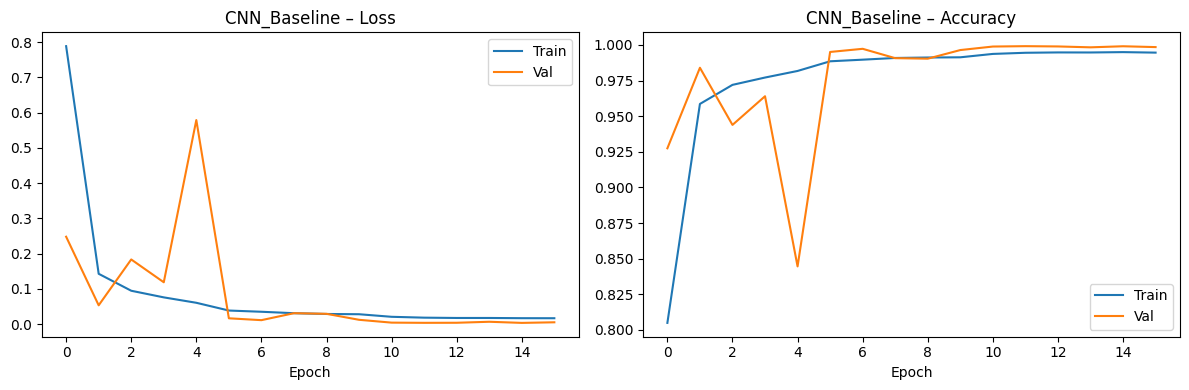

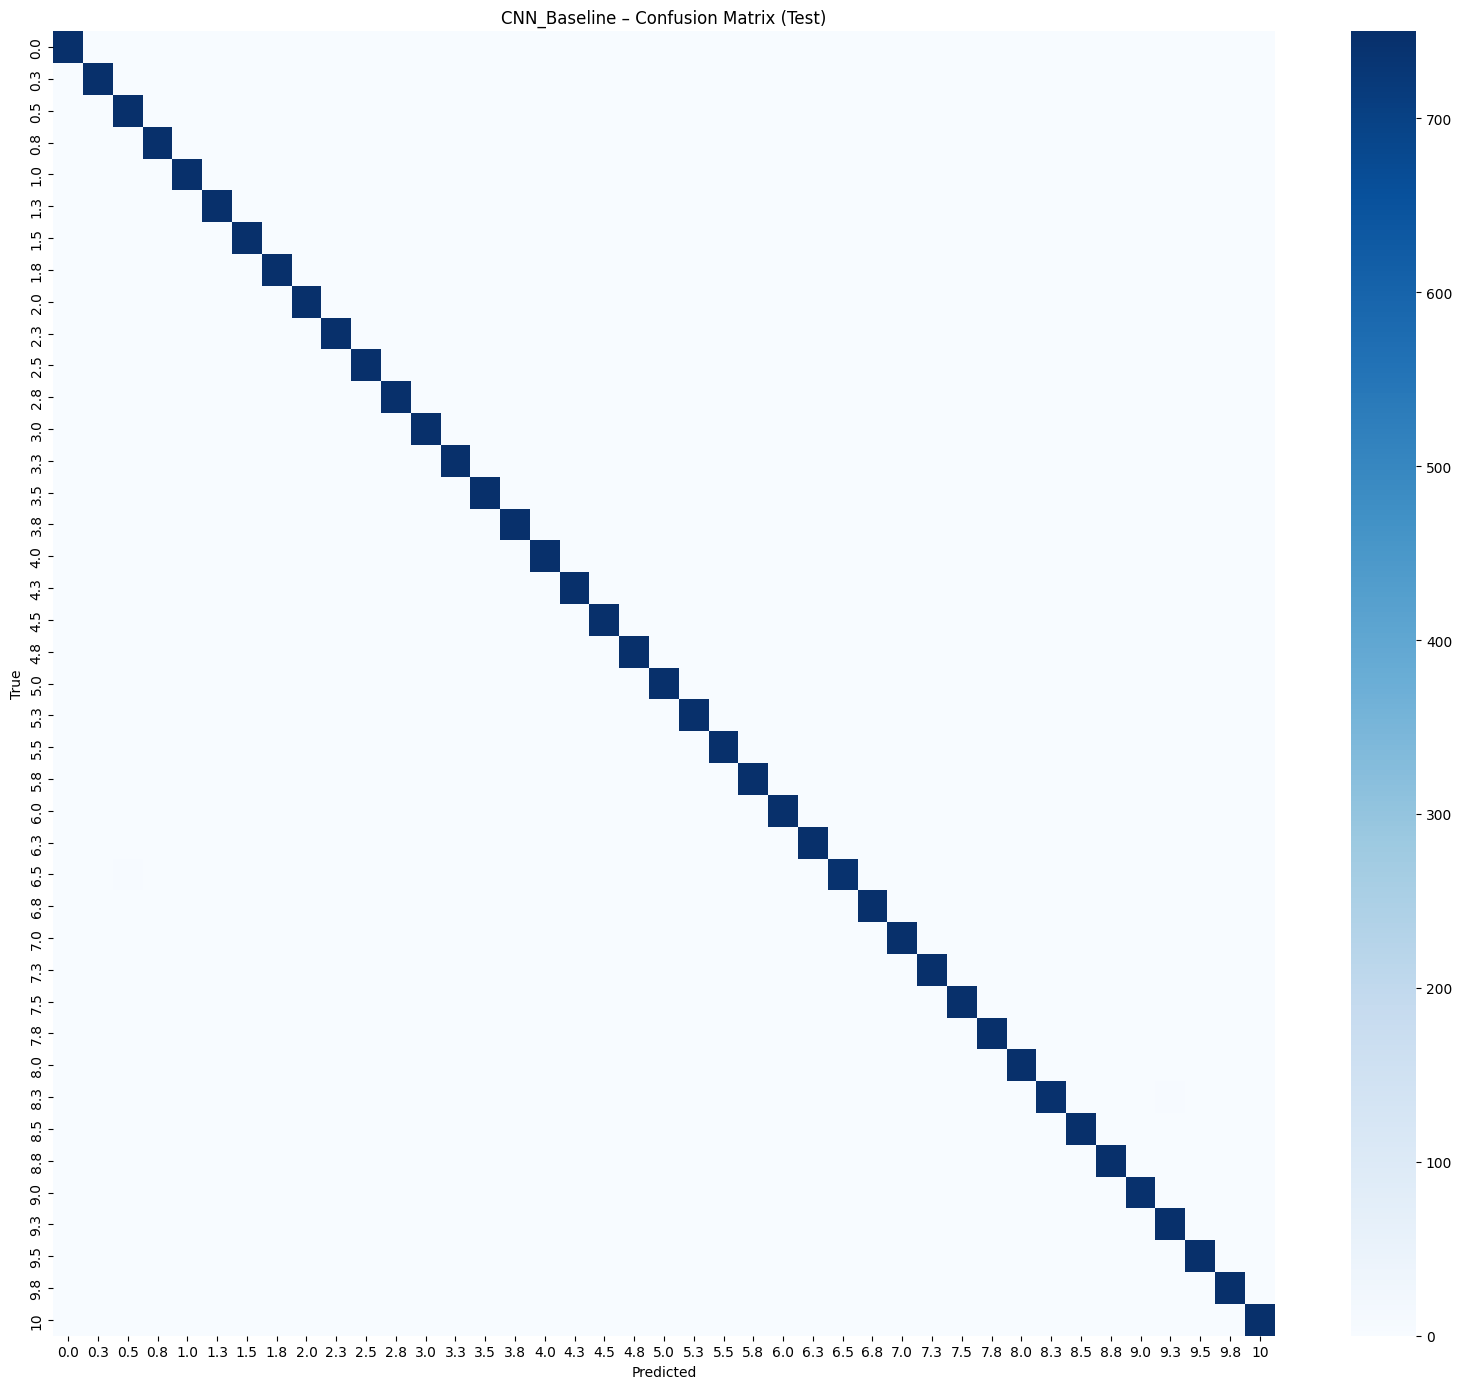

✅ CNN_Baseline done | Test Acc: 0.9987

Training: ResNet18
[ResNet18] Epoch 01 | Train Loss: 0.2480 Acc: 0.9305 | Val Loss: 0.0677 Acc: 0.9824 ← BEST
[ResNet18] Epoch 02 | Train Loss: 0.0962 Acc: 0.9743 | Val Loss: 0.0275 Acc: 0.9929 ← BEST
[ResNet18] Epoch 03 | Train Loss: 0.0743 Acc: 0.9808 | Val Loss: 0.0468 Acc: 0.9878 (patience 1/5)
[ResNet18] Epoch 04 | Train Loss: 0.0583 Acc: 0.9844 | Val Loss: 0.0235 Acc: 0.9937 ← BEST
[ResNet18] Epoch 05 | Train Loss: 0.0465 Acc: 0.9874 | Val Loss: 0.0370 Acc: 0.9912 (patience 1/5)
[ResNet18] Epoch 06 | Train Loss: 0.0428 Acc: 0.9883 | Val Loss: 0.0120 Acc: 0.9969 ← BEST
[ResNet18] Epoch 07 | Train Loss: 0.0373 Acc: 0.9902 | Val Loss: 0.0108 Acc: 0.9968 ← BEST
[ResNet18] Epoch 08 | Train Loss: 0.0319 Acc: 0.9914 | Val Loss: 0.0110 Acc: 0.9966 (patience 1/5)
[ResNet18] Epoch 09 | Train Loss: 0.0287 Acc: 0.9923 | Val Loss: 0.0117 Acc: 0.9969 (patience 2/5)
[ResNet18] Epoch 10 | Train Loss: 0.0264 Acc: 0.9924 | Val Loss: 0.0107 Acc: 0.9974 (patie

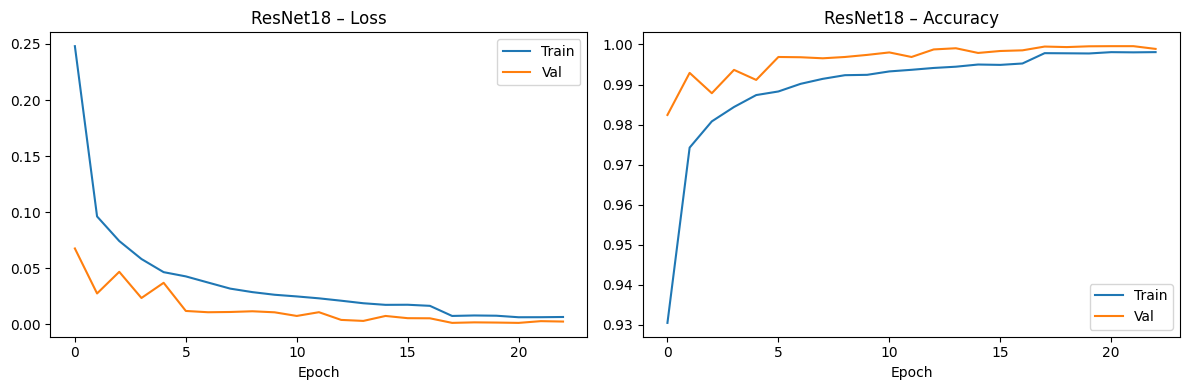

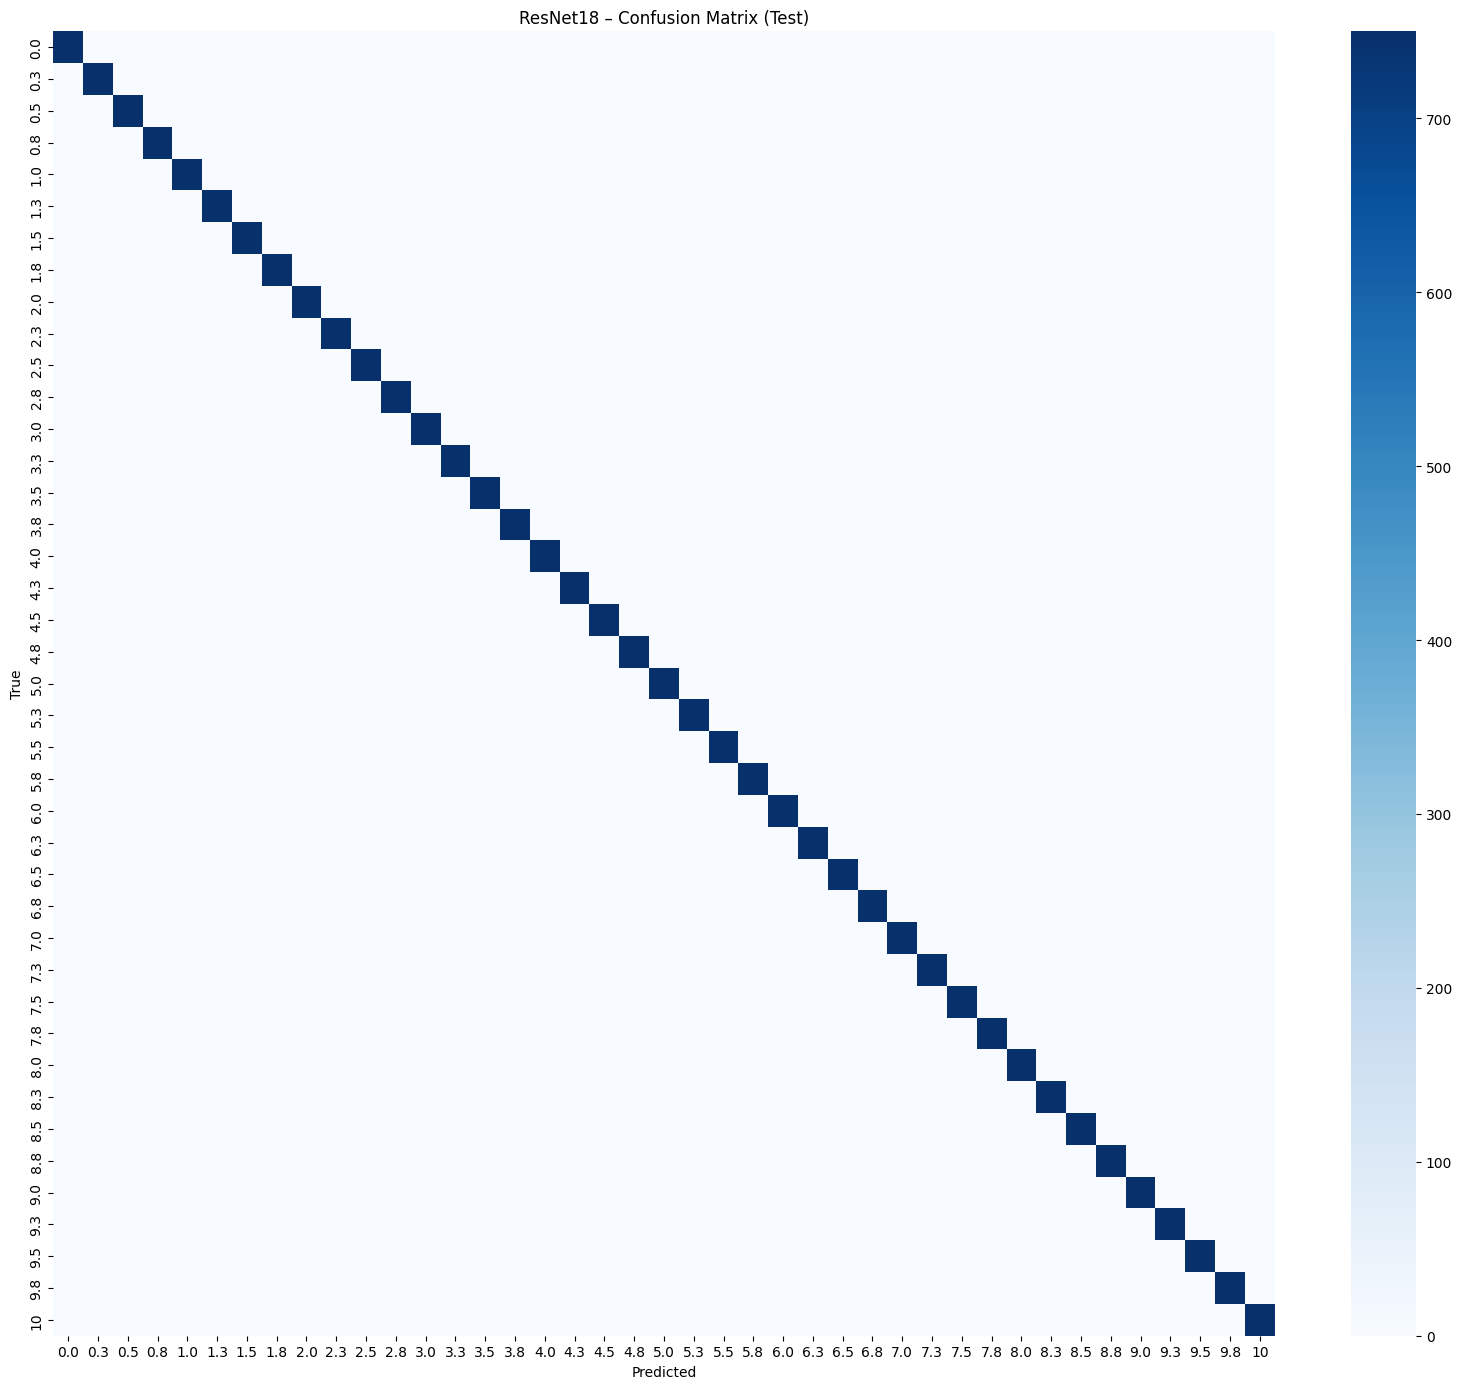

✅ ResNet18 done | Test Acc: 0.9997

Training: EfficientNet_B0
[EfficientNet_B0] Epoch 01 | Train Loss: 0.3630 Acc: 0.8966 | Val Loss: 0.0507 Acc: 0.9849 ← BEST
[EfficientNet_B0] Epoch 02 | Train Loss: 0.0914 Acc: 0.9741 | Val Loss: 0.0327 Acc: 0.9908 ← BEST
[EfficientNet_B0] Epoch 03 | Train Loss: 0.0663 Acc: 0.9814 | Val Loss: 0.0207 Acc: 0.9945 ← BEST
[EfficientNet_B0] Epoch 04 | Train Loss: 0.0528 Acc: 0.9848 | Val Loss: 0.0172 Acc: 0.9951 ← BEST
[EfficientNet_B0] Epoch 05 | Train Loss: 0.0470 Acc: 0.9863 | Val Loss: 0.0169 Acc: 0.9948 (patience 1/5)
[EfficientNet_B0] Epoch 06 | Train Loss: 0.0415 Acc: 0.9882 | Val Loss: 0.0117 Acc: 0.9968 ← BEST
[EfficientNet_B0] Epoch 07 | Train Loss: 0.0347 Acc: 0.9899 | Val Loss: 0.0072 Acc: 0.9979 ← BEST
[EfficientNet_B0] Epoch 08 | Train Loss: 0.0325 Acc: 0.9907 | Val Loss: 0.0074 Acc: 0.9980 (patience 1/5)
[EfficientNet_B0] Epoch 09 | Train Loss: 0.0300 Acc: 0.9912 | Val Loss: 0.0118 Acc: 0.9970 (patience 2/5)
[EfficientNet_B0] Epoch 10 | Tra

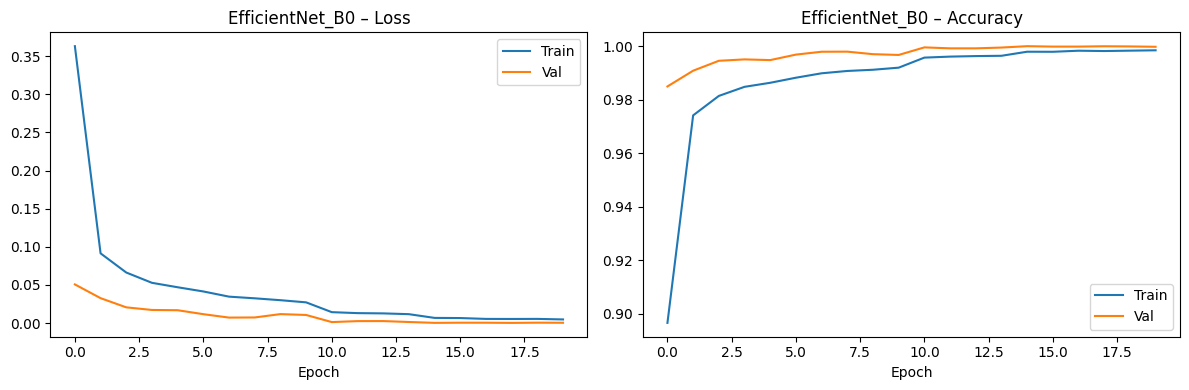

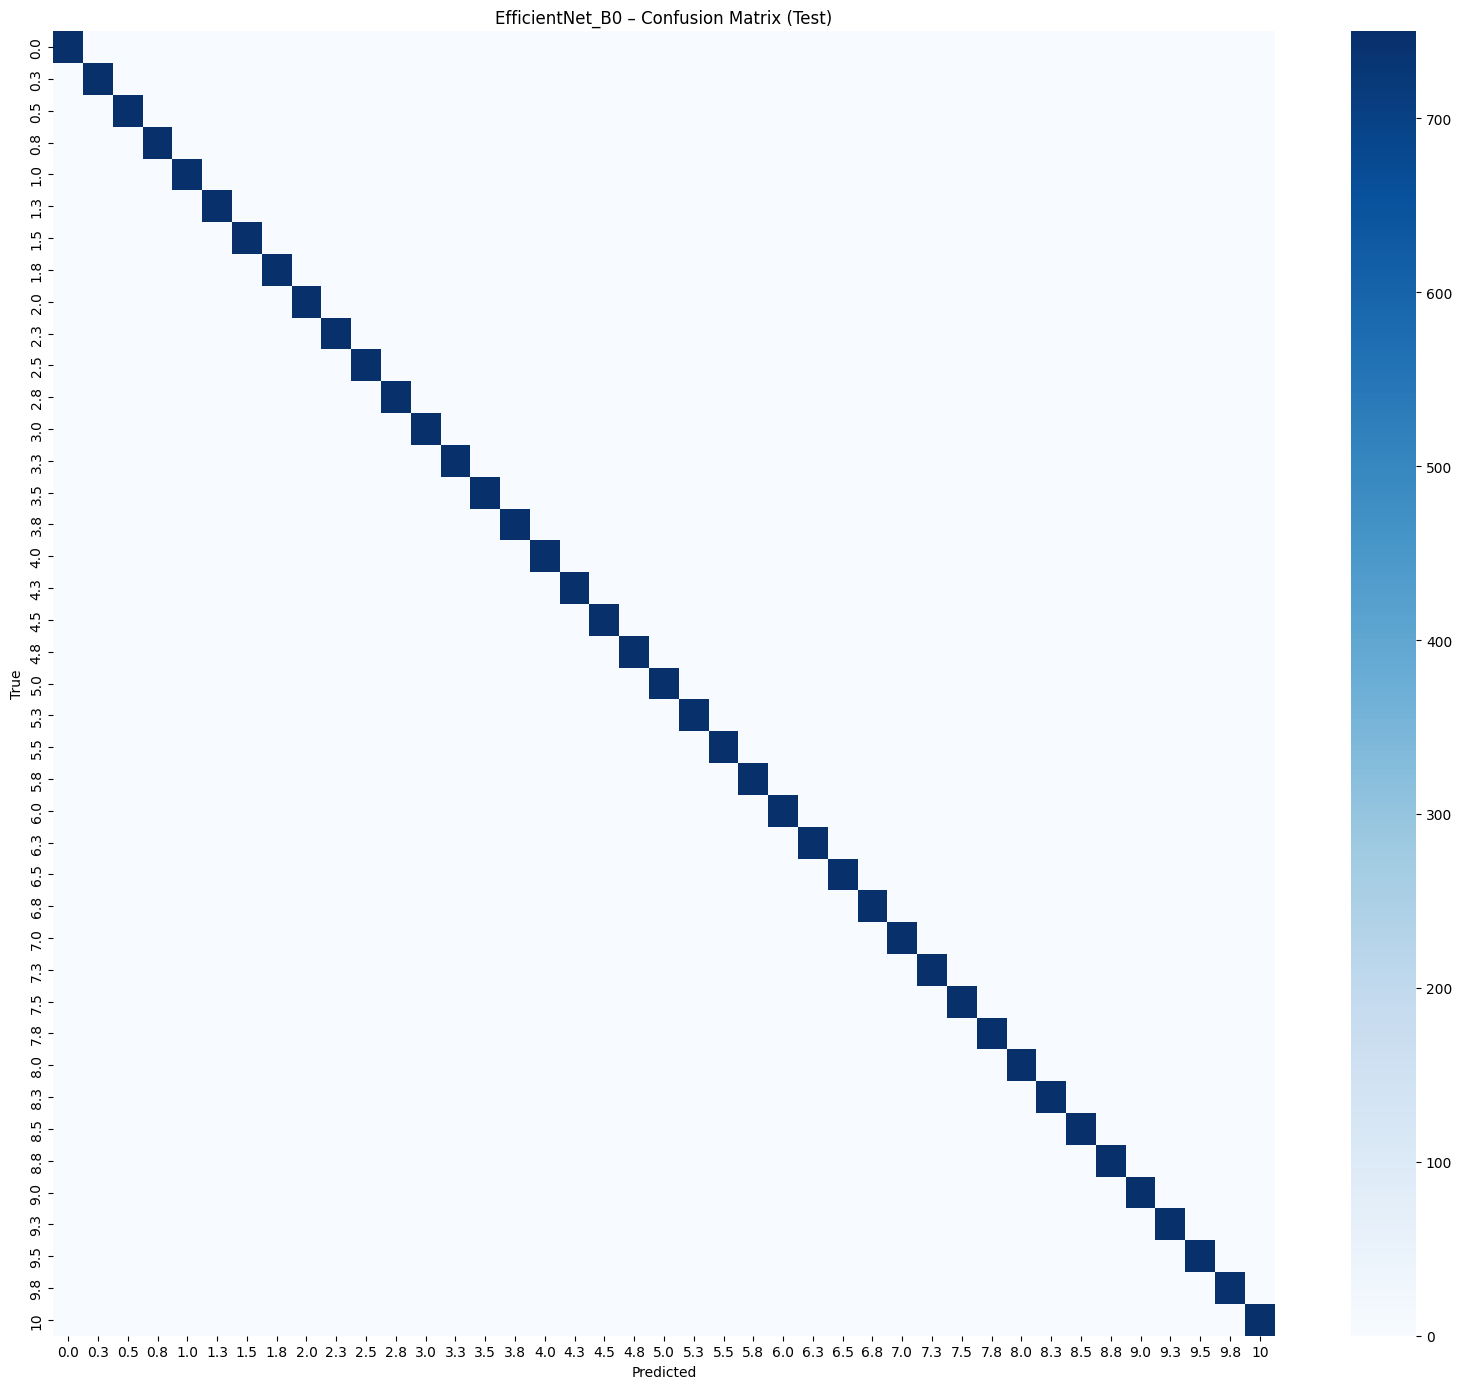

✅ EfficientNet_B0 done | Test Acc: 0.9998

Training: EfficientNet_B3
[EfficientNet_B3] Epoch 01 | Train Loss: 0.3649 Acc: 0.8980 | Val Loss: 0.0728 Acc: 0.9812 ← BEST
[EfficientNet_B3] Epoch 02 | Train Loss: 0.0802 Acc: 0.9781 | Val Loss: 0.0255 Acc: 0.9931 ← BEST
[EfficientNet_B3] Epoch 03 | Train Loss: 0.0598 Acc: 0.9838 | Val Loss: 0.0296 Acc: 0.9917 (patience 1/5)
[EfficientNet_B3] Epoch 04 | Train Loss: 0.0473 Acc: 0.9873 | Val Loss: 0.0142 Acc: 0.9968 ← BEST
[EfficientNet_B3] Epoch 05 | Train Loss: 0.0412 Acc: 0.9887 | Val Loss: 0.0122 Acc: 0.9963 ← BEST
[EfficientNet_B3] Epoch 06 | Train Loss: 0.0348 Acc: 0.9905 | Val Loss: 0.0100 Acc: 0.9970 ← BEST
[EfficientNet_B3] Epoch 07 | Train Loss: 0.0305 Acc: 0.9917 | Val Loss: 0.0089 Acc: 0.9974 ← BEST
[EfficientNet_B3] Epoch 08 | Train Loss: 0.0261 Acc: 0.9928 | Val Loss: 0.0047 Acc: 0.9986 ← BEST
[EfficientNet_B3] Epoch 09 | Train Loss: 0.0246 Acc: 0.9934 | Val Loss: 0.0088 Acc: 0.9973 (patience 1/5)
[EfficientNet_B3] Epoch 10 | Trai

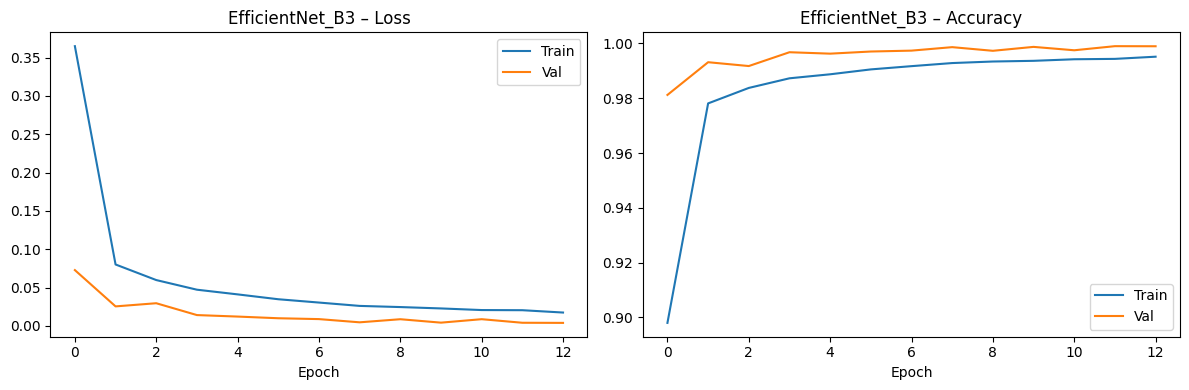

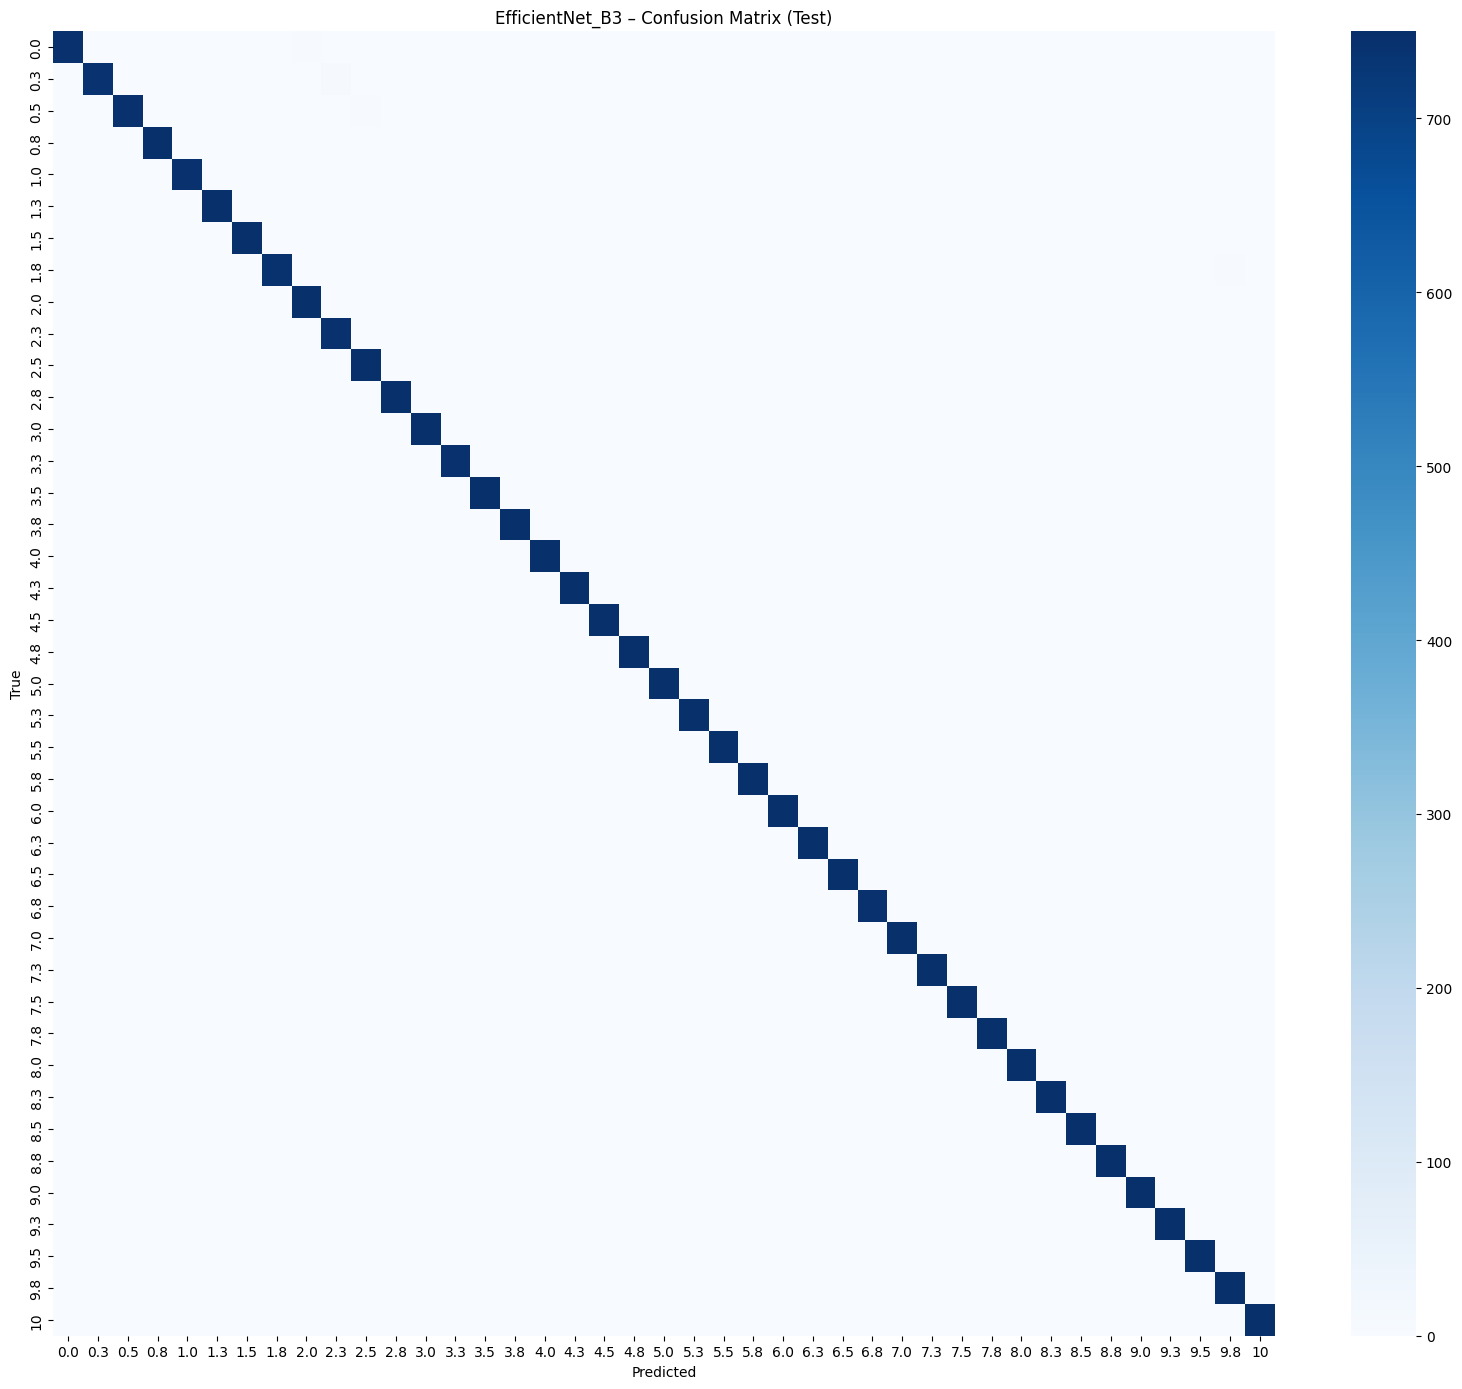

✅ EfficientNet_B3 done | Test Acc: 0.9977

Training: MobileNetV3
[MobileNetV3] Epoch 01 | Train Loss: 0.7371 Acc: 0.7754 | Val Loss: 0.2569 Acc: 0.9191 ← BEST
[MobileNetV3] Epoch 02 | Train Loss: 0.2721 Acc: 0.9149 | Val Loss: 0.2697 Acc: 0.9156 (patience 1/5)
[MobileNetV3] Epoch 03 | Train Loss: 0.2152 Acc: 0.9322 | Val Loss: 0.1277 Acc: 0.9590 ← BEST
[MobileNetV3] Epoch 04 | Train Loss: 0.1802 Acc: 0.9432 | Val Loss: 0.2478 Acc: 0.9218 (patience 1/5)
[MobileNetV3] Epoch 05 | Train Loss: 0.1583 Acc: 0.9509 | Val Loss: 0.0750 Acc: 0.9759 ← BEST
[MobileNetV3] Epoch 06 | Train Loss: 0.1387 Acc: 0.9566 | Val Loss: 0.0766 Acc: 0.9749 (patience 1/5)
[MobileNetV3] Epoch 07 | Train Loss: 0.1290 Acc: 0.9600 | Val Loss: 0.0690 Acc: 0.9785 ← BEST
[MobileNetV3] Epoch 08 | Train Loss: 0.1173 Acc: 0.9636 | Val Loss: 0.1032 Acc: 0.9667 (patience 1/5)
[MobileNetV3] Epoch 09 | Train Loss: 0.1091 Acc: 0.9662 | Val Loss: 0.0562 Acc: 0.9823 ← BEST
[MobileNetV3] Epoch 10 | Train Loss: 0.1030 Acc: 0.9681 |

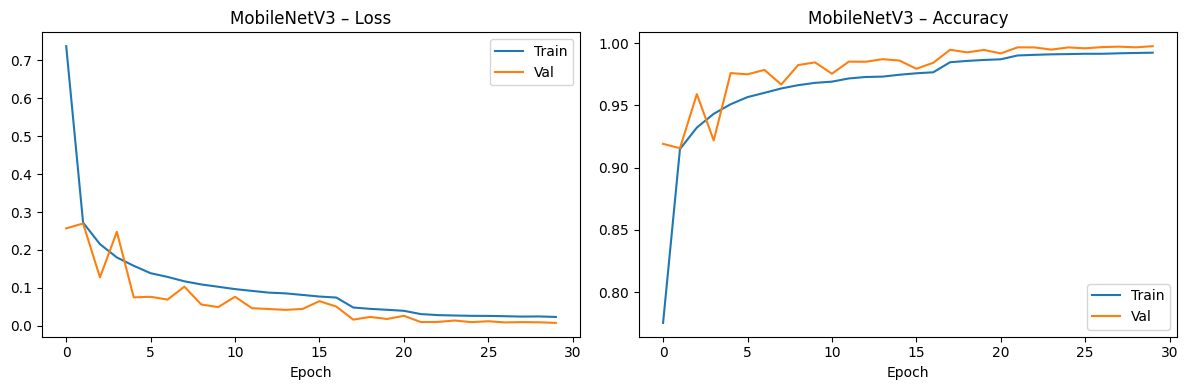

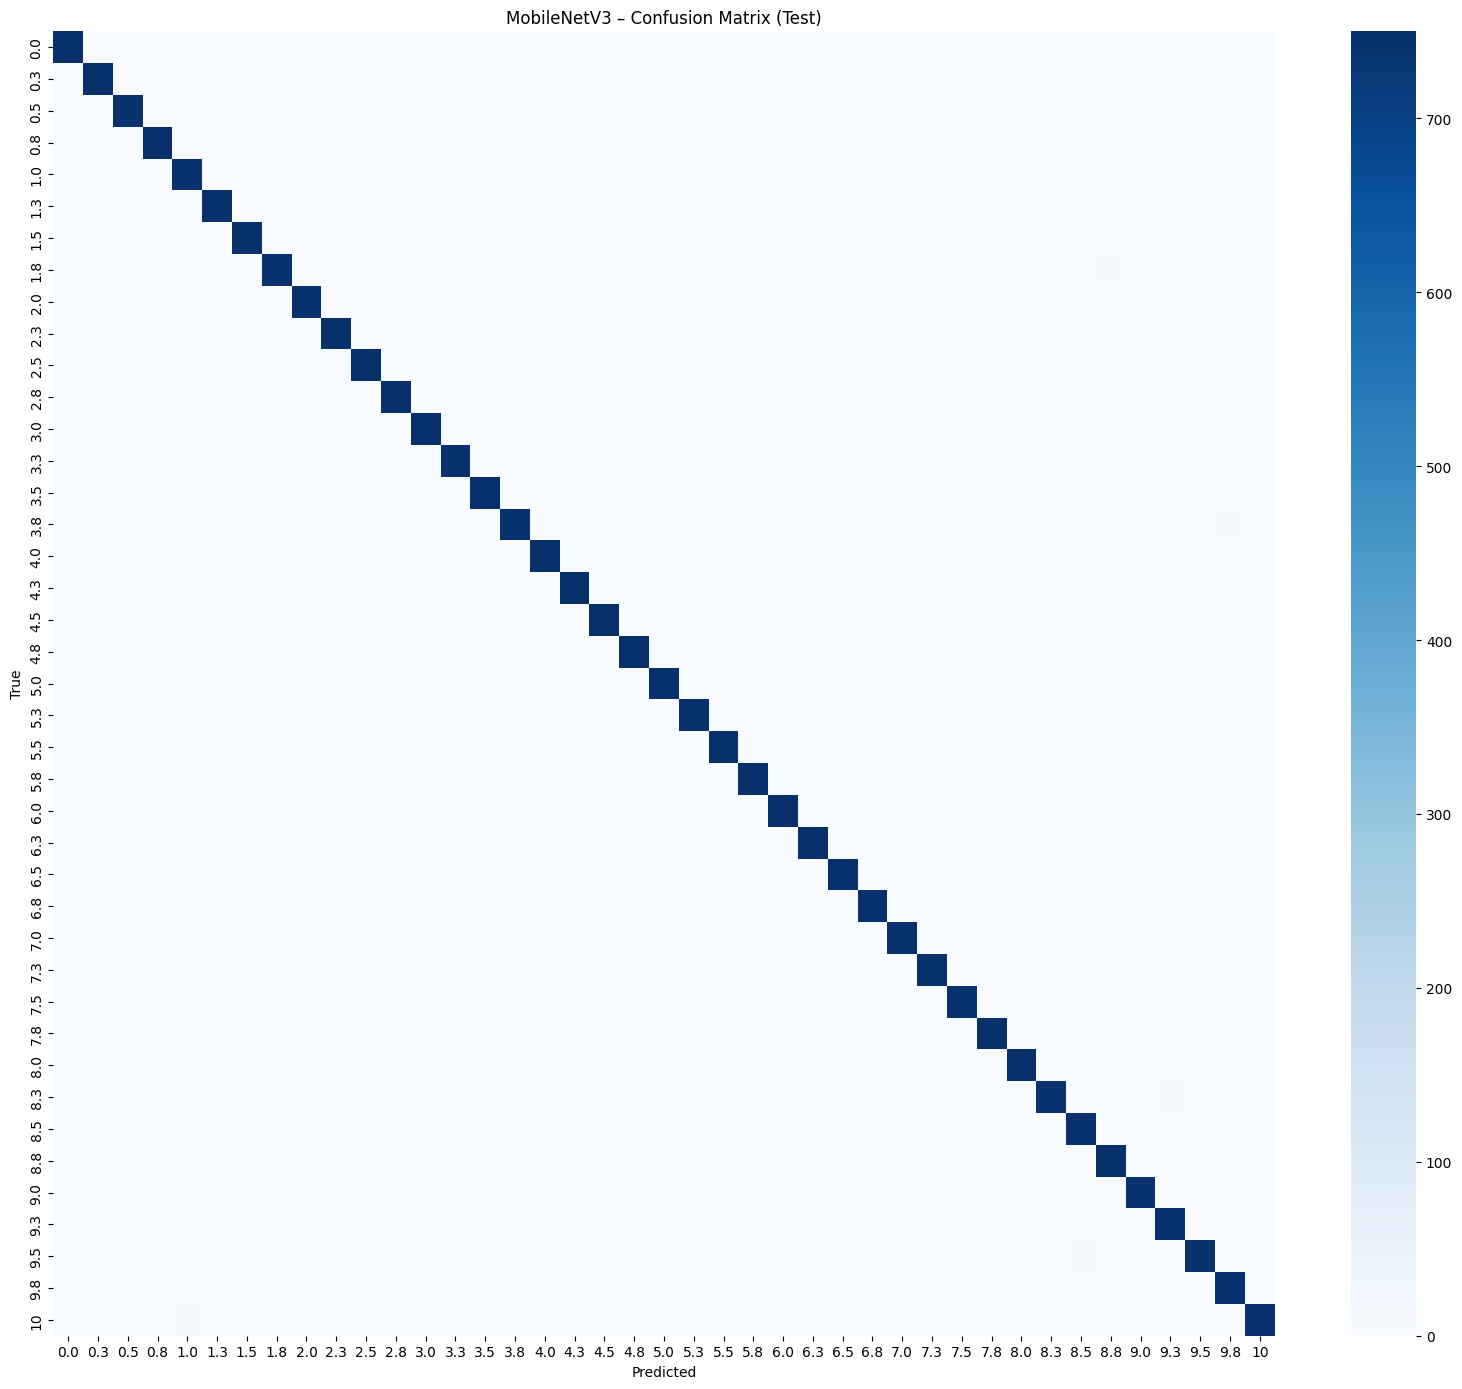

✅ MobileNetV3 done | Test Acc: 0.9970

Training: DeiT_Tiny
[DeiT_Tiny] Epoch 01 | Train Loss: 2.0635 Acc: 0.4172 | Val Loss: 0.3074 Acc: 0.9058 ← BEST
[DeiT_Tiny] Epoch 02 | Train Loss: 0.2625 Acc: 0.9161 | Val Loss: 0.1579 Acc: 0.9470 ← BEST
[DeiT_Tiny] Epoch 03 | Train Loss: 0.1629 Acc: 0.9477 | Val Loss: 0.1026 Acc: 0.9672 ← BEST
[DeiT_Tiny] Epoch 04 | Train Loss: 0.1225 Acc: 0.9602 | Val Loss: 0.0729 Acc: 0.9768 ← BEST
[DeiT_Tiny] Epoch 05 | Train Loss: 0.1019 Acc: 0.9673 | Val Loss: 0.0593 Acc: 0.9803 ← BEST
[DeiT_Tiny] Epoch 06 | Train Loss: 0.0863 Acc: 0.9725 | Val Loss: 0.0522 Acc: 0.9838 ← BEST
[DeiT_Tiny] Epoch 07 | Train Loss: 0.0771 Acc: 0.9755 | Val Loss: 0.0483 Acc: 0.9837 ← BEST
[DeiT_Tiny] Epoch 08 | Train Loss: 0.0652 Acc: 0.9789 | Val Loss: 0.0391 Acc: 0.9879 ← BEST
[DeiT_Tiny] Epoch 09 | Train Loss: 0.0602 Acc: 0.9805 | Val Loss: 0.0519 Acc: 0.9834 (patience 1/5)
[DeiT_Tiny] Epoch 10 | Train Loss: 0.0541 Acc: 0.9825 | Val Loss: 0.0394 Acc: 0.9872 (patience 2/5)
[DeiT

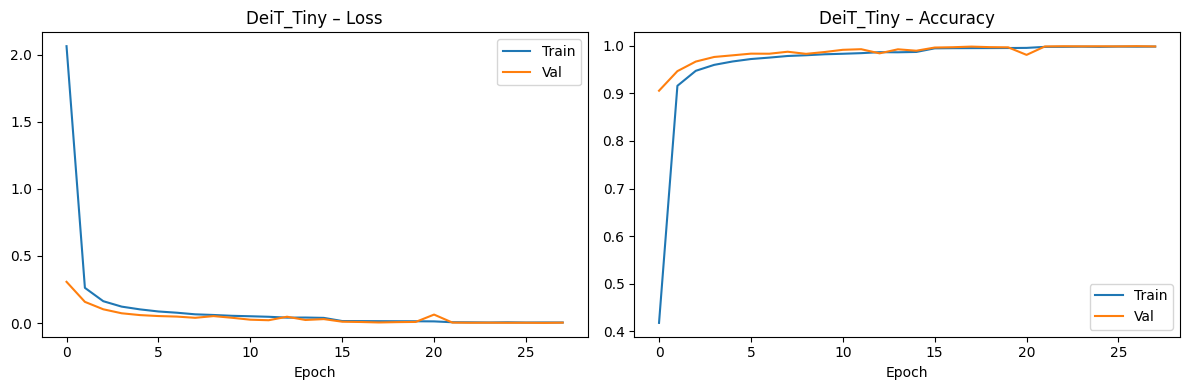

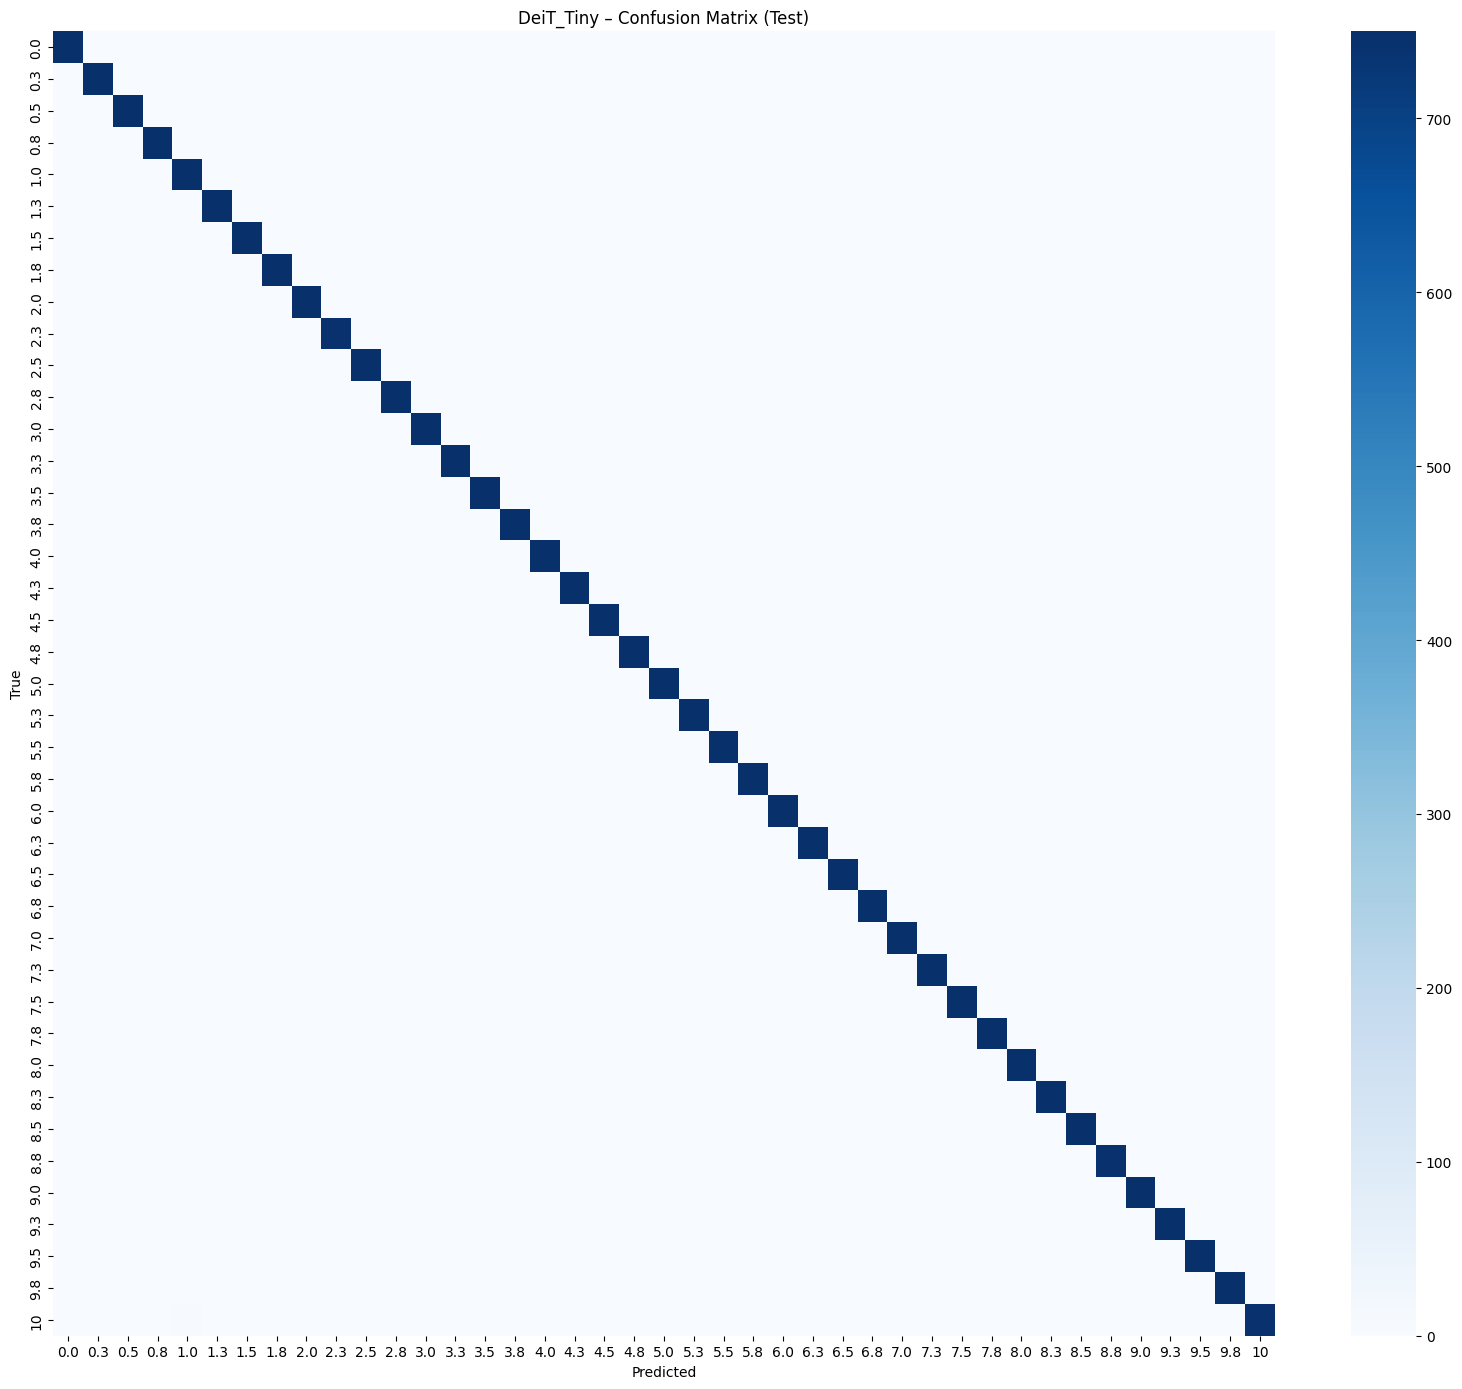

✅ DeiT_Tiny done | Test Acc: 0.9989

ALL MODELS DONE
  CNN_Baseline         | Test Acc: 0.9987
  ResNet18             | Test Acc: 0.9997
  EfficientNet_B0      | Test Acc: 0.9998
  EfficientNet_B3      | Test Acc: 0.9977
  MobileNetV3          | Test Acc: 0.9970
  DeiT_Tiny            | Test Acc: 0.9989


In [5]:
# Transform riêng cho DeiT
deit_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(8, fill=255),           # ← thêm fill=255
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), fill=255),  # ← thêm fill=255
    transforms.ColorJitter(brightness=0.15, contrast=0.15),  # ← giảm xuống
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
deit_val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

def get_loaders(is_deit=False):
    if is_deit:
        tr, vl = deit_train_transform, deit_val_transform
    else:
        tr, vl = train_transform, val_transform
    return (
        DataLoader(ScoreDataset(SPLITS/"train.csv", tr),
                   batch_size=CONFIG['batch_size'], shuffle=True,
                   num_workers=0, pin_memory=False),  # ← False
        DataLoader(ScoreDataset(SPLITS/"val.csv", vl),
                   batch_size=CONFIG['batch_size'], shuffle=False,
                   num_workers=0, pin_memory=False),  # ← False
        DataLoader(ScoreDataset(SPLITS/"test.csv", vl),
                   batch_size=CONFIG['batch_size'], shuffle=False,
                   num_workers=0, pin_memory=False),  # ← False
    )

# Danh sách models
model_configs = [
    ("CNN_Baseline",    CNNBaseline(),        False),
    ("ResNet18",        get_resnet18(),       False),
    ("EfficientNet_B0", get_efficientnet_b0(), False),
    ("EfficientNet_B3", get_efficientnet_b3(), False),
    ("MobileNetV3",     get_mobilenet_v3(),   False),
    ("DeiT_Tiny",       get_deit_tiny(),      True),
]

# Train tất cả
all_results = {}

for model_name, model, is_deit in model_configs:
    print(f"\n{'='*60}")
    print(f"Training: {model_name}")
    print(f"{'='*60}")

    train_loader, val_loader, test_loader = get_loaders(is_deit)

    trained_model, history = train_model(model, model_name)
    preds, labels = evaluate_model(trained_model, test_loader)
    acc, report = save_results(preds, labels, trained_model, model_name, history)

    plot_history(history, model_name)
    plot_confusion(preds, labels, model_name)

    all_results[model_name] = {
        "test_acc": acc,
        "best_val_loss": min(history['val_loss'])
    }
    print(f"✅ {model_name} done | Test Acc: {acc:.4f}")

print("\n" + "="*60)
print("ALL MODELS DONE")
print("="*60)
for name, res in all_results.items():
    print(f"  {name:20s} | Test Acc: {res['test_acc']:.4f}")